In [1]:
import warnings
warnings.filterwarnings('ignore')

(Tutorial_Get_hbond_site_directions)=
# Get hydrogen-bond site directions

*Deriving observed donor vectors and bounded ideal acceptor hypotheses.*

You can separate fixed-state chemical recognition from a local directional model.
This experimental tool returns finite unit directions, supporting atoms and the
periodic images actually used. It does not calculate orbitals or optimize hydrogen
positions. The detached dictionary leaves the system's domains unchanged.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

See {func}`molsysmt.interactions.hbonds.get_hbond_site_directions` for inputs, outputs and errors.
:::


## Basic usage

Let's show how this function works with a controlled aldehyde graph and its explicit
carbonyl plane. RDKit constructs the declared chemistry; no conformer generator is
needed. The function also accepts native MolSys, supported complementary topology/
structures and H5MSM inputs supplying all required attributes.


In [2]:
import molsysmt as msm

In [3]:
from rdkit import Chem
import numpy as np
from molsysmt import pyunitwizard as puw

# A controlled carbonyl plane in angstroms; no embedding or optimization.
molsys = Chem.MolFromSmiles('CC=O')
conformer = Chem.Conformer(3)
for atom, position in enumerate([(0, 1, 0), (0, 0, 0), (1, 0, 0)]):
    conformer.SetAtomPosition(atom, position)
_ = molsys.AddConformer(conformer)
result = msm.interactions.hbonds.get_hbond_site_directions(molsys, pbc=False)
print(result['directions'])
print(result['codes'], result['status'].tolist())
assert result['direction_indices'].tolist() == [0, 1]
assert np.allclose(result['directions'][:, 0], 0.5)

[[ 0.5        0.8660254  0.       ]
 [ 0.5       -0.8660254 -0.       ]]
{'site_roles': {0: 'donor', 1: 'acceptor'}, 'site_models': {0: 'unsupported', 1: 'observed_donor_hydrogen', 2: 'carbonyl_trigonal', 3: 'aromatic_nitrogen_bisector', 4: 'nitrile_linear'}, 'status': {0: 'unsupported', 1: 'defined', 2: 'undefined'}} [[1]]


## Interpreting directions

The origin is the acceptor O. Its two ideal directions make 120 degrees with O→C
and occupy the plane defined by O, C and an indexed C substituent. They are local
hypotheses, not an assertion that both directions form an interaction.
Direction 0 follows the reference substituent's transverse projection; direction
1 has the opposite sign. The lowest-index heavy C substituent is the reference,
otherwise the lowest-index indexed H. Reordering atoms can change these slot labels.


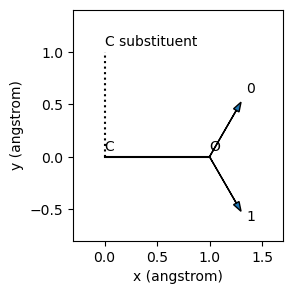

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot([0, 1], [0, 0], 'k-', label='C–O bond')
ax.plot([0, 0], [0, 1], 'k:')
for index, direction in enumerate(result['directions']):
    ax.arrow(1, 0, direction[0] * 0.6, direction[1] * 0.6,
             head_width=0.06, length_includes_head=True)
    ax.text(1 + direction[0] * 0.7, direction[1] * 0.7, str(index))
for x, y, label in [(0, 0, 'C'), (1, 0, 'O'), (0, 1, 'C substituent')]:
    ax.text(x, y + 0.06, label)
ax.set(xlabel='x (angstrom)', ylabel='y (angstrom)', xlim=(-.3, 1.7), ylim=(-.8, 1.4))
ax.set_aspect('equal')
plt.show()

## Choosing chemistry and coverage

`method='ideal_local_geometry'` names the geometric profile. `site_method` selects
the separate recognition rule; its original metadata and attribution remain in
`result['sites']`. The default uses `smarts_donor_acceptor`. Elemental rules do not
turn all nitrogen/oxygen atoms into geometrically supported acceptors.

| Recognized environment | Directions | Requirement |
| --- | --- | --- |
| Indexed donor–H pair | One observed D→H direction | Both atoms selected, nonzero bond |
| Neutral ordinary aldehyde/ketone/amide carbonyl O | Two ideal in-plane trigonal directions | Declared C=O and indexed noncollinear C substituent |
| Neutral pyridine-like aromatic N | One opposite bisector of normalized neighbor bonds | Two indexed neighbors and nondegenerate geometry |
| Neutral nitrile N | One opposite N→C direction | Declared triple bond and nonzero bond |

Esters, acids/carboxylates, amines, ether/alcohol/water O, sulfur/phosphorus and
metal-bound acceptors are unsupported in this first profile. No implicit protonation,
H addition or pocket-dependent refinement is performed. RDKit is an optional
dependency required by this profile's chemical matching, including elemental recognition.


In [5]:
nitrile = Chem.MolFromSmiles('C#N')
nitrile_conformer = Chem.Conformer(2)
nitrile_conformer.SetAtomPosition(0, (0, 0, 0))
nitrile_conformer.SetAtomPosition(1, (1, 0, 0))
_ = nitrile.AddConformer(nitrile_conformer)
linear = msm.interactions.hbonds.get_hbond_site_directions(nitrile, pbc=False)
assert np.allclose(linear['directions'], [[1, 0, 0]])
print(linear['sites']['method'], linear['method'], linear['site_models'])

smarts_donor_acceptor ideal_local_geometry [4]


## Distinguishing missing directions

Each site/structure has uint8 status: `0` unsupported chemistry, `1` defined geometry,
`2` undefined geometry. Defined directions occupy a sparse numeric table; no NaN or
arbitrary fallback direction is returned for unsupported or undefined sites. The
status matrix explicitly preserves those outcomes. A missing indexed plane reference
cannot be replaced by a virtual hydrogen or a global axis. Coincident/collinear
support geometry is undefined; nonfinite coordinates and singular boxes raise.


In [6]:
unresolved = Chem.MolFromSmiles('C=O.O')
unresolved_conformer = Chem.Conformer(3)
for atom, position in enumerate([(0, 0, 0), (1, 0, 0), (2, 0, 0)]):
    unresolved_conformer.SetAtomPosition(atom, position)
_ = unresolved.AddConformer(unresolved_conformer)
missing = msm.interactions.hbonds.get_hbond_site_directions(unresolved, pbc=False)
print(missing['status'], missing['directions'].shape)
assert missing['status'].tolist() == [[2, 0]]

[[2 0]] (0, 3)


## Selecting sites and structures

Select acceptor anchors independently of supporting neighbors: complete source
chemistry provides those neighbors even outside the selection. Donor pairs survive
only if both D and indexed H are selected. Preserve requested structure order and
repetitions. `direction_structure_indices` contains source indices;
`direction_structure_positions` contains positions in the requested axis.


In [7]:
from molsysmt.native import Structures
native = msm.convert(molsys, to_form='molsysmt.MolSys')
coordinates = puw.get_value(native.structures.coordinates, to_unit='nm')
native.structures = Structures(coordinates=puw.quantity(np.repeat(coordinates, 4, axis=0), 'nm'))
selected = msm.interactions.hbonds.get_hbond_site_directions(
    native, selection=[2], structure_indices=[3, 0, 3], pbc=False, heavy_mode='force')
assert selected['support_atom_indices'].tolist() == [2, 1, 0]
assert selected['direction_structure_indices'].tolist() == [3, 3, 0, 0, 3, 3]
assert selected['direction_structure_positions'].tolist() == [0, 0, 1, 1, 2, 2]
print(selected['evaluated_structure_indices'], selected['status'].shape)
empty = msm.interactions.hbonds.get_hbond_site_directions(native, structure_indices=[], pbc=False)
assert empty['directions'].shape == (0, 3) and empty['status'].shape == (0, 1)

[3 0 3] (3, 1)


## Choosing stored states

Use `chemical_state='reference'`, an explicit index, or `'structure'`. All requested
structures must share one known state for the last option. The selected state is
retained without modifying the source reference. Stored formal charges, orders and
atom/bond aromatic flags are required; absence is not silently repaired.


In [8]:
msm.set(native, structure_chemical_state_index=[0, 0, 0, 0])
state_geometry = msm.interactions.hbonds.get_hbond_site_directions(
    native, chemical_state='structure', structure_indices=[3, 0], pbc=False)
assert state_geometry['chemical_state_index'] == 0
print(state_geometry['chemical_state_index'])

0


## Reconstructing periodic support

For row-vector boxes, each support position is `r + image @ box`. The anchor's
image is zero. Carbonyl images compose the observed O→C and C→substituent bond
images; they do not re-infer an image from a scalar distance. Direction records
reference static support membership through `direction_site_indices`; their
`image_offsets` index packed `image_vectors` in that same support order.


In [9]:
periodic = msm.convert(molsys, to_form='molsysmt.MolSys')
cell = np.eye(3)
shifts = np.array([[1, -1, 0], [0, 1, 0], [-1, 0, 0]])
periodic.structures.coordinates = puw.quantity(coordinates + shifts @ cell, 'nm')
periodic.structures.box = puw.quantity(cell[None], 'nm')
images = msm.interactions.hbonds.get_hbond_site_directions(periodic, pbc=True)
begin, end = images['image_offsets'][:2]
print(images['image_vectors'][begin:end])
assert np.array_equal(images['image_vectors'][begin:end], shifts[2] - shifts[[2, 1, 0]])
assert np.allclose(images['directions'], result['directions'])

[[ 0  0  0]
 [-1 -1  0]
 [-2  1  0]]


## Presenting units

Unit directions are dimensionless NumPy arrays. Origins are length quantities
presented with your active PyUnitWizard standard units and output backend. Internal
coordinate blocks use nanometers. No pharmacophore projection distance is inferred.


In [10]:
with puw.context(standard_units=['angstrom', 'ps']):
    angstrom_result = msm.interactions.hbonds.get_hbond_site_directions(molsys, pbc=False)
    assert puw.has_unit(angstrom_result['origins'], 'angstrom')
    assert np.allclose(puw.get_value(angstrom_result['origins'], to_unit='angstrom'), [[1, 0, 0], [1, 0, 0]])
    assert np.allclose(angstrom_result['directions'], result['directions'])
    print(angstrom_result['origins'])

[[0.9999999999999998 0.0 0.0] [0.9999999999999998 0.0 0.0]] angstrom


## Reading bounded geometry

`heavy_mode='force'` requests declared streaming; `'auto'` chooses delivery and
`'off'` requests bounded eager work. Project only supporting atoms and process
coordinates through ChunkedExecutor. Sparse output and the per-site status matrix
must still fit the numerical RAM estimate: this is not an unlimited disk writer.
Source graphs/Python overhead are outside that estimate. `max_matches` bounds each
chemical query before selection; exceeding it raises, without truncation.


In [11]:
from tempfile import TemporaryDirectory
from pathlib import Path
with TemporaryDirectory() as workspace:
    path = str(Path(workspace) / 'carbonyl.h5msm')
    msm.convert(native, to_form=path)
    disk = msm.interactions.hbonds.get_hbond_site_directions(
        path, structure_indices=[3, 0], chemical_state='structure', heavy_mode='force', pbc=False)
    assert np.allclose(disk['directions'], state_geometry['directions'])
    assert disk['direction_structure_indices'].tolist() == [3, 3, 0, 0]
print(disk['execution'])

{'execution': 'chunked', 'numeric_ram_budget': 16736008192}


## Retaining scientific provenance

The result separates the recognition bibliography in `sites` from the geometric
method, evidence and actual producer versions. RDKit's [feature-direction helpers](https://www.rdkit.org/docs/source/rdkit.Chem.Features.FeatDirUtilsRD.html)
inspired these ideal hypotheses; their exact implementation behavior is not
reproduced or certified. In particular, this carbonyl model returns two finite
in-plane vectors, not a cone. Optional Ackredit records completed calculations,
distinguishing geometric inspiration from executed software.

Keep the detached dictionary with your derived workflow. It is not an Interactions
analysis, is not attached automatically and has no native named H5MSM persistence
route. H5MSM in the example stores the molecular inputs, not this direction dictionary.
For observed interactions, use {ref}`Tutorial_Get_hbonds` and the
{ref}`persistence recipe <Cookbook_Saving_hbond_interactions>`.

:::{seealso}
:class: dropdown

- {ref}`Tutorial_Get_hbond_sites` — chemical recognition, {func}`molsysmt.interactions.hbonds.get_hbond_sites`.
- {ref}`Tutorial_Get_vectors` — general observed pair geometry, {func}`molsysmt.structure.get_vectors`.
- {ref}`Tutorial_Get_hbonds` — classified sparse interactions, {func}`molsysmt.interactions.hbonds.get_hbonds`.
:::
